# Suite 1 — Macro-Level Performance & Baseline Benchmarking

**Goal:** prove the ML adds value over trivial baselines at the state-wide (50Hertz) level.

Sources: `results/macro_cv_metrics.csv` (aggregate per-fold metrics for all 7 models) and `results/macro_oof_predictions.parquet` (honest out-of-fold per-point predictions for the tree/glass-box models, from `src.evaluation.export_predictions`). BiLSTM/TFT have no per-point export (heavy to refit) so they appear only in the aggregate bars.

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [2]:
cv = pd.read_csv("results/macro_cv_metrics.csv")
oof = pd.read_parquet("results/macro_oof_predictions.parquet")
oof["timestamp"] = pd.to_datetime(oof["timestamp"], utc=True)
print(cv["model"].unique(), "| oof models:", oof["model"].unique())
cv.groupby(["model","technology","scale"]).size().head()

<ArrowStringArray>
['persistence', 'climatology', 'lightgbm', 'xgboost', 'ebm', 'bilstm', 'tft']
Length: 7, dtype: str | oof models: <ArrowStringArray>
['lightgbm', 'xgboost', 'ebm']
Length: 3, dtype: str


model        technology  scale
bilstm       solar       cf       4
                         mw       4
             wind        cf       4
                         mw       4
climatology  solar       cf       4
dtype: int64

## 1a — CV metric bars across all architectures + baselines (CF scale)

saved -> results/figures/s1_macro_cv_metric_bars.png


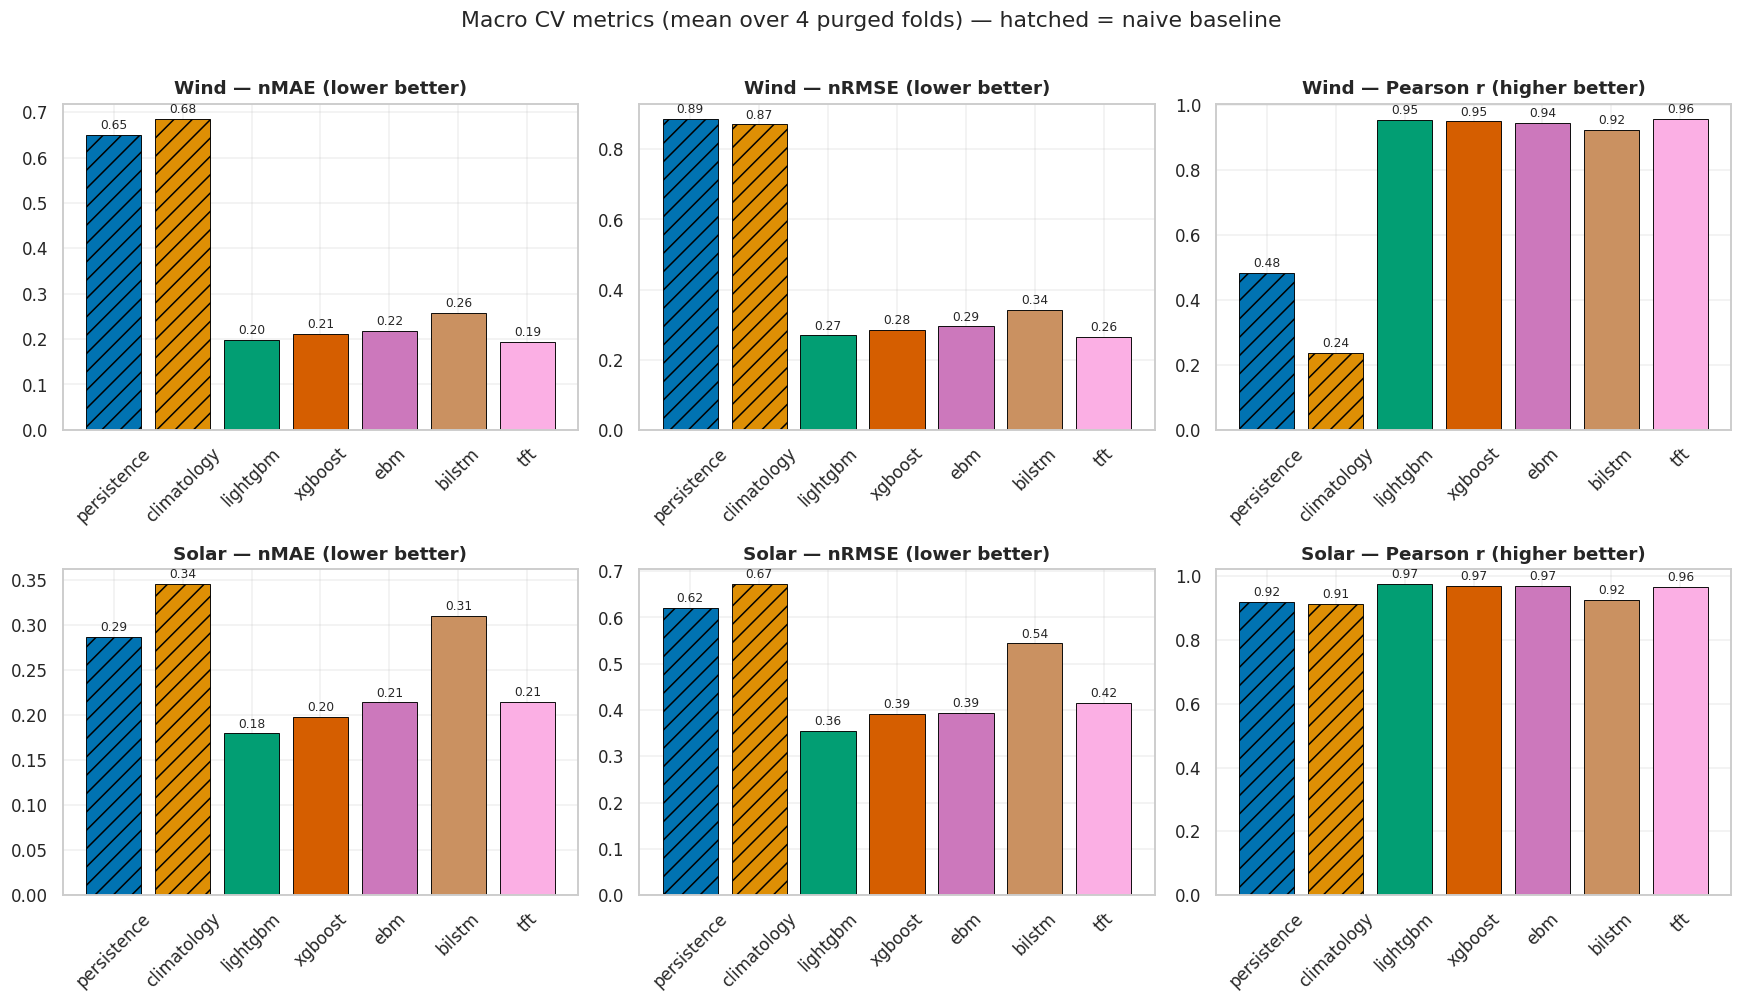

In [3]:
# CF scale is the common denominator (TFT only has CF rows) and is the actual
# modeling target. Average across the 4 purged folds.
cf = cv[cv["scale"] == "cf"].copy()
agg = cf.groupby(["technology","model"]).agg(
    nmae=("nmae","mean"), nrmse=("nrmse","mean"), corr=("corr","mean")
).reset_index()
agg["model"] = pd.Categorical(agg["model"], MODEL_ORDER, ordered=True)
agg = agg.sort_values(["technology","model"])

metrics = [("nmae","nMAE (lower better)"), ("nrmse","nRMSE (lower better)"), ("corr","Pearson r (higher better)")]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for r, tech in enumerate(["wind","solar"]):
    sub = agg[agg["technology"] == tech]
    for c, (m, title) in enumerate(metrics):
        ax = axes[r, c]
        colors = [PAL[mm] for mm in sub["model"]]
        bars = ax.bar(sub["model"].astype(str), sub[m], color=colors,
                      edgecolor="black", linewidth=0.6)
        for mm, b in zip(sub["model"], bars):
            if mm in BASELINES: b.set_hatch("//")
        ax.set_title(f"{tech.title()} — {title}")
        ax.tick_params(axis="x", rotation=45)
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
fig.suptitle("Macro CV metrics (mean over 4 purged folds) — hatched = naive baseline", y=1.01)
fig.tight_layout(); save(fig, "s1_macro_cv_metric_bars.png"); plt.show()

## 1b — R² for the tree/glass-box models (from OOF per-point predictions)

saved -> results/figures/s1_macro_r2_tree_models.png


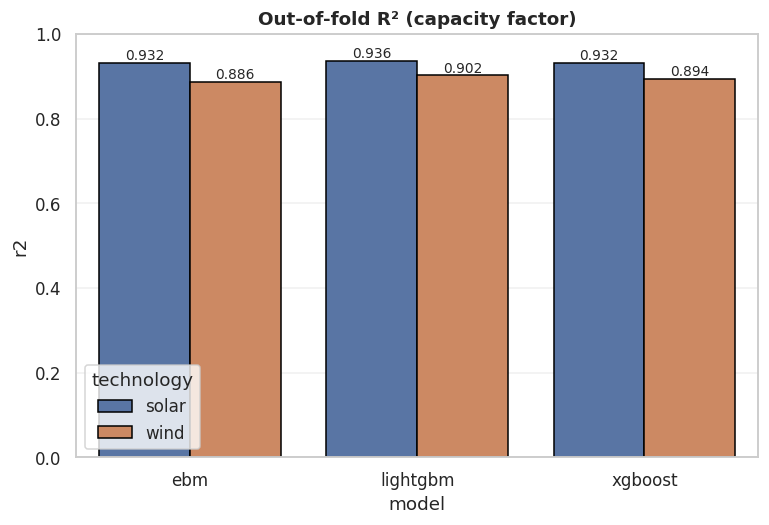

,technology,model,r2
0,solar,ebm,0.931771
1,solar,lightgbm,0.936196
2,solar,xgboost,0.932049
3,wind,ebm,0.886471
4,wind,lightgbm,0.901962
5,wind,xgboost,0.894263


In [4]:
# R^2 needs per-point preds, exported only for the tree models. corr (1a) covers
# the rest. R^2 = 1 - SSE/SST on the held-out CF.
def r2(y, p):
    y, p = np.asarray(y), np.asarray(p)
    ss_res = np.sum((y - p) ** 2); ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

rows = []
for (tech, model), g in oof.groupby(["technology","model"]):
    rows.append(dict(technology=tech, model=model, r2=r2(g["y_cf"], g["pred_cf"])))
r2df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(r2df, x="model", y="r2", hue="technology", ax=ax, edgecolor="black")
ax.set_title("Out-of-fold R² (capacity factor)"); ax.set_ylim(0, 1)
for c in ax.containers: ax.bar_label(c, fmt="%.3f", fontsize=9)
save(fig, "s1_macro_r2_tree_models.png"); plt.show(); r2df

## 1c — Time-series overlay: actual vs OOF prediction vs 24h persistence

Auto-selects a single ~5-day window (shared by wind and solar) with the highest combined variability from the LightGBM out-of-fold series. The second plot zooms into the last 24h of that window.

saved -> results/figures/s1_timeseries_overlay.png


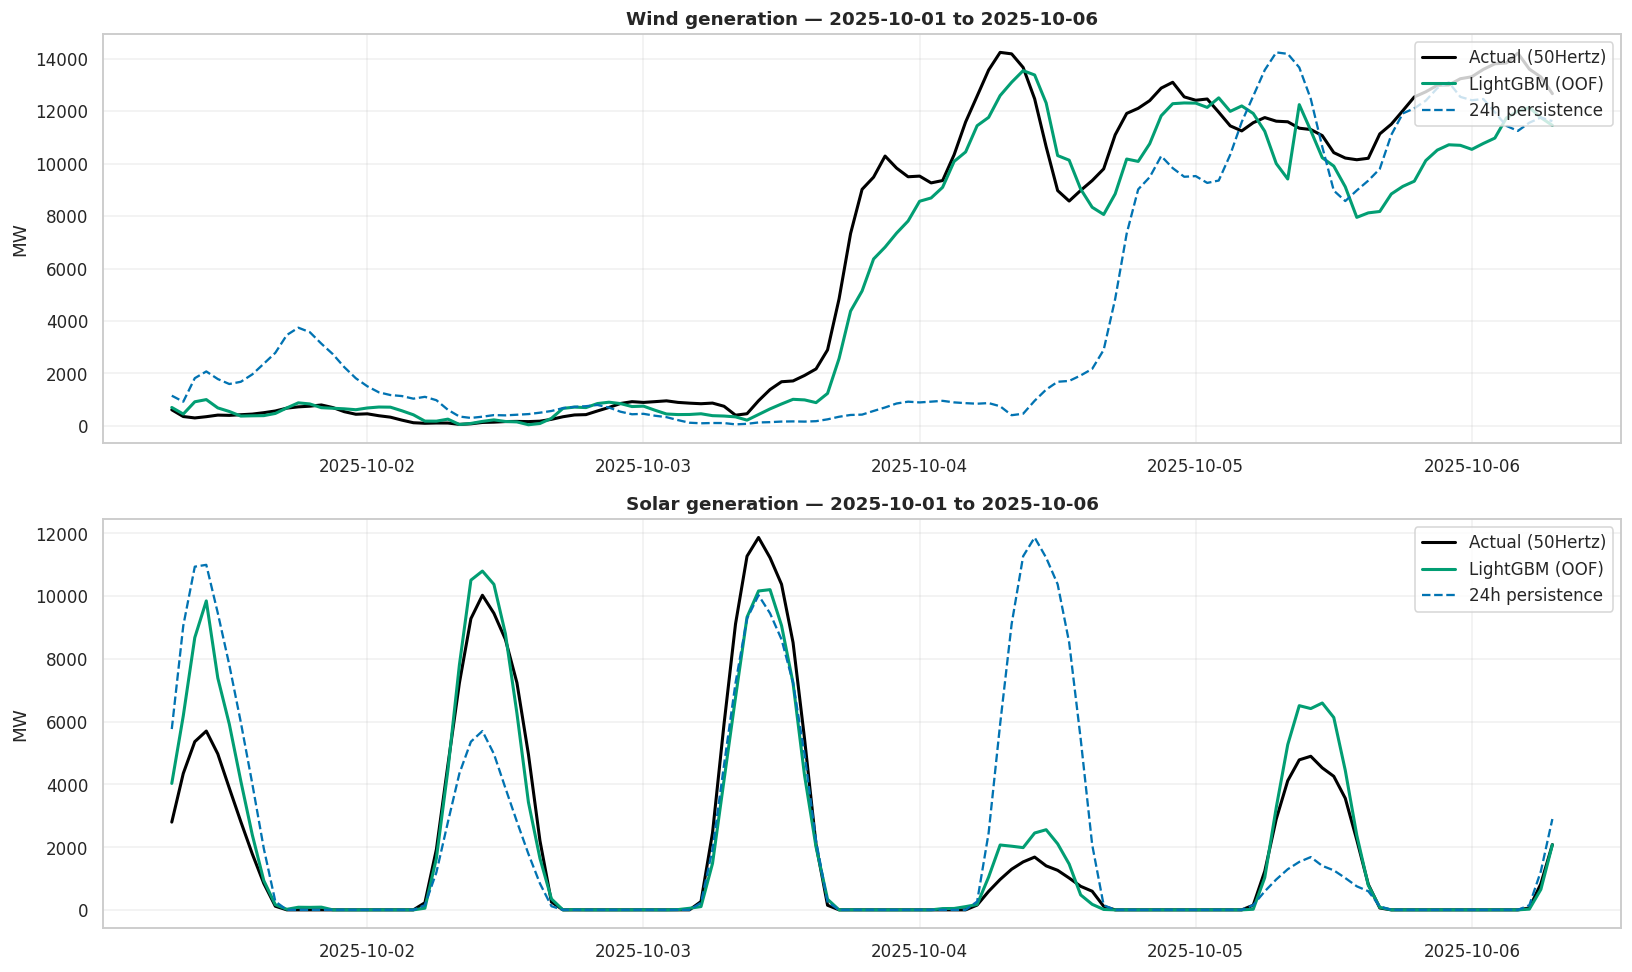

In [5]:
def busiest_window(*series, days=5):
    """Start/end of the rolling window with the largest combined (z-normalized)
    variance across series, so wind and solar share one window."""
    w = 24 * days
    score = sum(s.rolling(w).std() / s.std() for s in series)
    end = score.idxmax()
    start = end - pd.Timedelta(hours=w)
    return start, end

wind_ser = oof[(oof.model == "lightgbm") & (oof.technology == "wind")].sort_values("timestamp").set_index("timestamp")
solar_ser = oof[(oof.model == "lightgbm") & (oof.technology == "solar")].sort_values("timestamp").set_index("timestamp")
start, end = busiest_window(wind_ser["y_mw"], solar_ser["y_mw"])
sl = slice(start, end)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
for ax, tech, ser in zip(axes, ["wind", "solar"], [wind_ser, solar_ser]):
    # ponytail: positional shift(24) is valid within a contiguous hourly fold;
    # the busiest window sits mid-fold so boundary misalignment is a non-issue.
    pers = ser["y_mw"].shift(24)
    ax.plot(ser.loc[sl].index, ser.loc[sl, "y_mw"], color="black", lw=2, label="Actual (50Hertz)")
    ax.plot(ser.loc[sl].index, ser.loc[sl, "pred_mw"], color=PAL["lightgbm"], lw=2, label="LightGBM (OOF)")
    ax.plot(pers.loc[sl].index, pers.loc[sl], color=PAL["persistence"], lw=1.5, ls="--", label="24h persistence")
    ax.set_title(f"{tech.title()} generation — {start.date()} to {end.date()}")
    ax.set_ylabel("MW"); ax.legend(loc="upper right")
fig.tight_layout(); save(fig, "s1_timeseries_overlay.png"); plt.show()

saved -> results/figures/s1_timeseries_overlay_24h.png


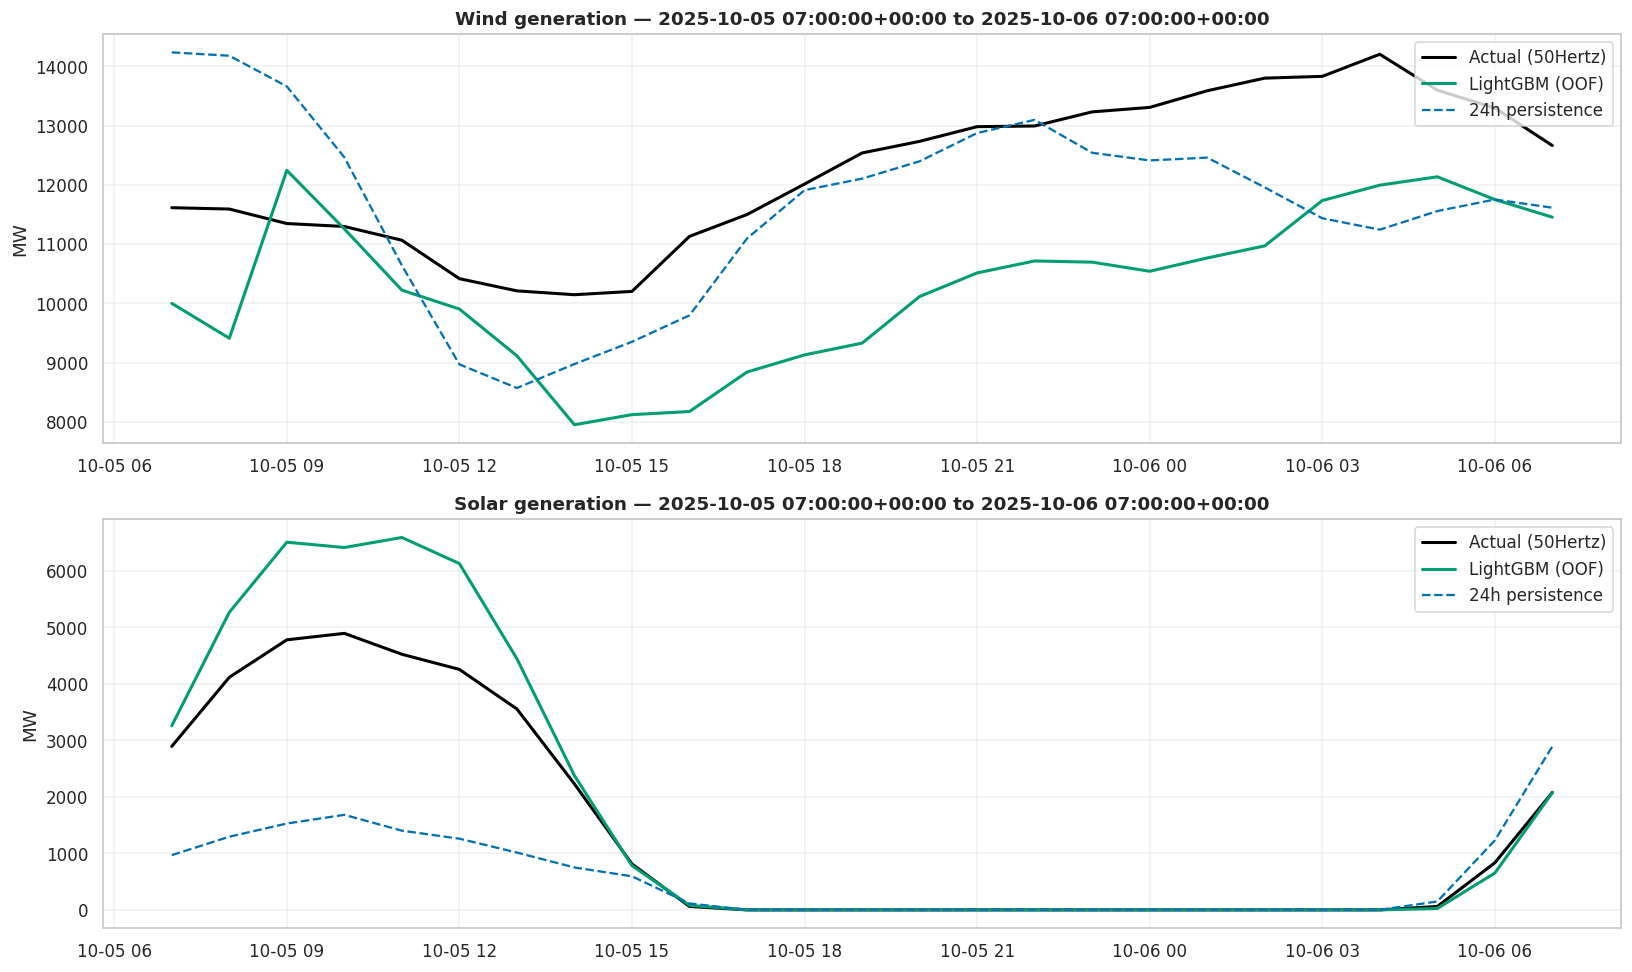

In [6]:
zoom_start, zoom_end = end - pd.Timedelta(hours=24), end
sl24 = slice(zoom_start, zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
for ax, tech, ser in zip(axes, ["wind", "solar"], [wind_ser, solar_ser]):
    pers = ser["y_mw"].shift(24)
    ax.plot(ser.loc[sl24].index, ser.loc[sl24, "y_mw"], color="black", lw=2, label="Actual (50Hertz)")
    ax.plot(ser.loc[sl24].index, ser.loc[sl24, "pred_mw"], color=PAL["lightgbm"], lw=2, label="LightGBM (OOF)")
    ax.plot(pers.loc[sl24].index, pers.loc[sl24], color=PAL["persistence"], lw=1.5, ls="--", label="24h persistence")
    ax.set_title(f"{tech.title()} generation — {zoom_start} to {zoom_end}")
    ax.set_ylabel("MW")
    ax.legend(loc="upper right")

fig.tight_layout()
save(fig, "s1_timeseries_overlay_24h.png")
plt.show()

## 1d — Target vs prediction scatter with y=x reference (OOF)

saved -> results/figures/s1_scatter_pred_vs_actual.png


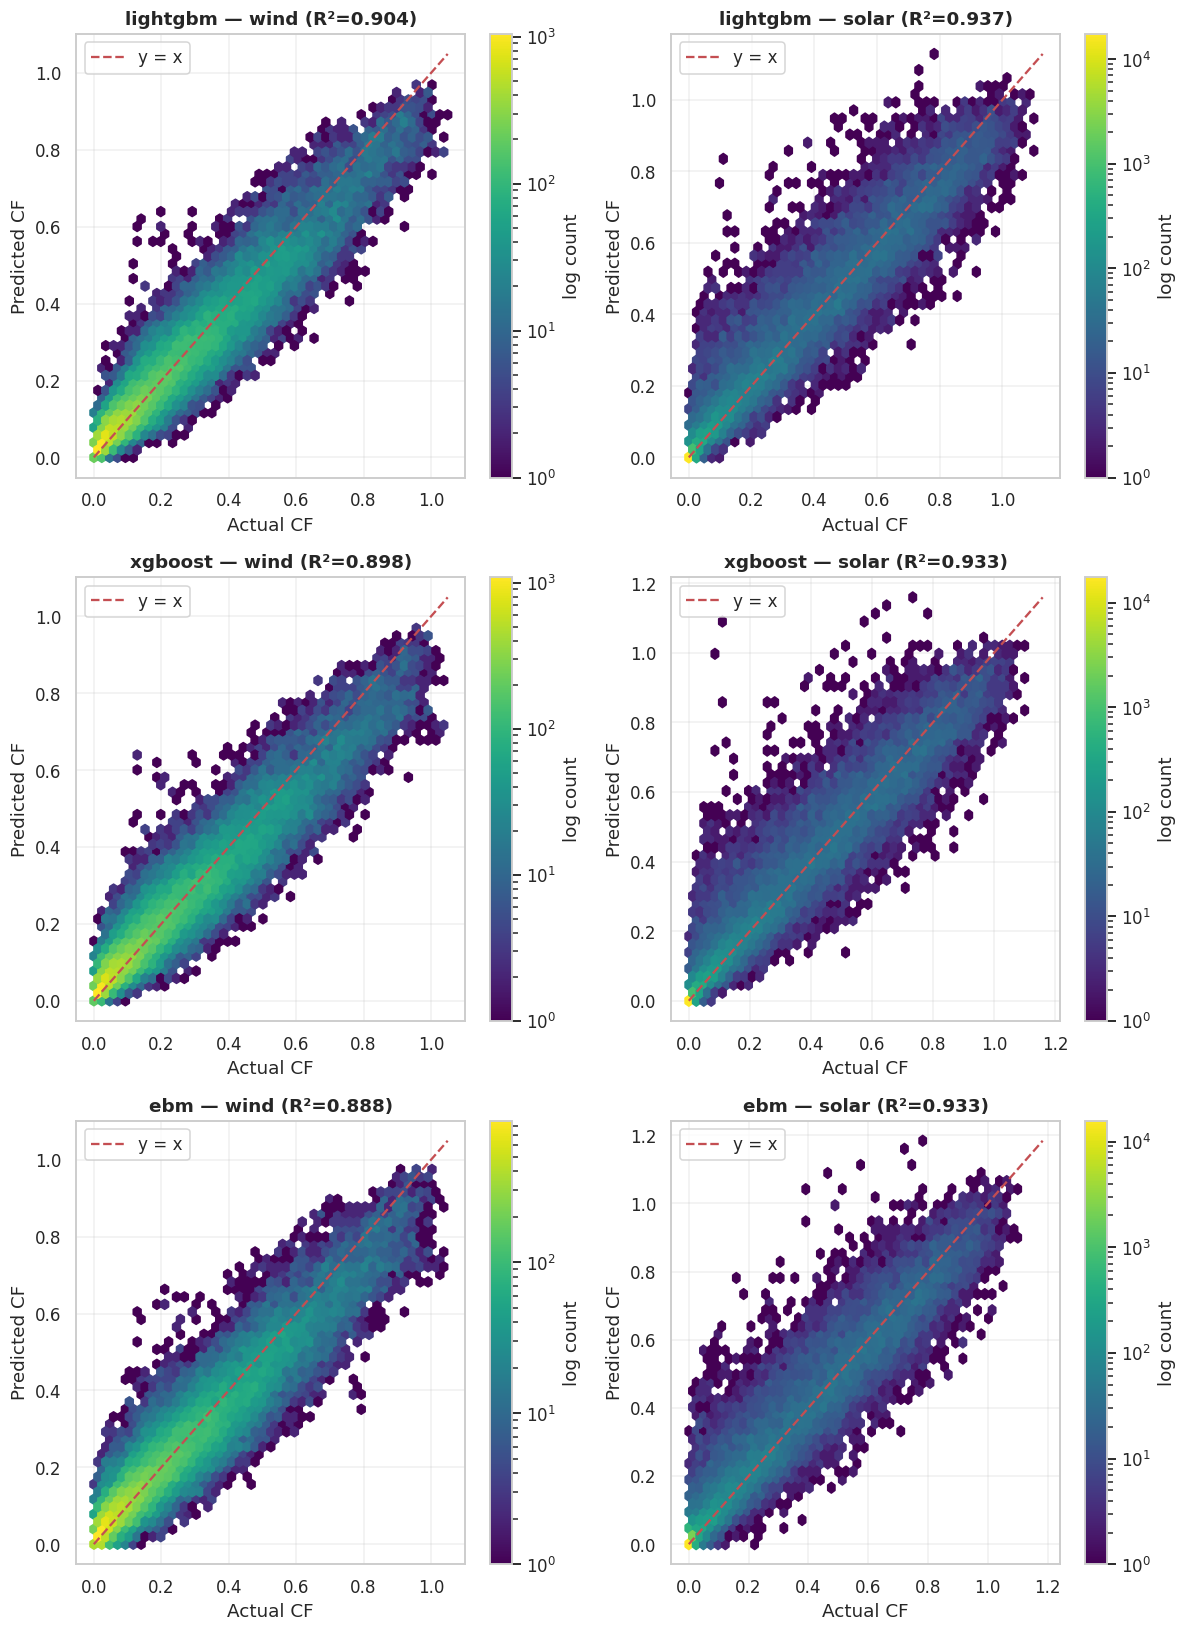

In [7]:
models = ["lightgbm","xgboost","ebm"]
fig, axes = plt.subplots(3, 2, figsize=(11, 15))
for r, model in enumerate(models):
    for c, tech in enumerate(["wind","solar"]):
        ax = axes[r, c]
        g = oof[(oof.model == model) & (oof.technology == tech)]
        hb = ax.hexbin(g["y_cf"], g["pred_cf"], gridsize=45, cmap="viridis", mincnt=1, bins="log")
        lim = [0, max(g["y_cf"].max(), g["pred_cf"].max())]
        ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
        rr = np.corrcoef(g["y_cf"], g["pred_cf"])[0,1] ** 2
        ax.set_title(f"{model} — {tech} (R²={rr:.3f})")
        ax.set_xlabel("Actual CF"); ax.set_ylabel("Predicted CF"); ax.legend(loc="upper left")
        fig.colorbar(hb, ax=ax, label="log count")
fig.tight_layout(); save(fig, "s1_scatter_pred_vs_actual.png"); plt.show()